In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
# --- Plot settings ---
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'Helvetica'
sns.set(font='Helvetica')
sns.set_theme(style="ticks", rc={"axes.spines.right": False, "axes.spines.top": False})

In [3]:
extracted_data = pd.read_csv("data/merged_master_table.tsv", sep="\t")

/var/folders/0g/vgd6zzjs45j1nj2f3h3jv1zw0000gn/T/ipykernel_80620/3977915606.py:1: DtypeWarning: Columns (0: ptu, 1: scaffold_oid, 2: source_type, 3: ecosystem, 4: putatively_complete, 5: mob_genes, 6: t4cp_genes, 7: t4ss_atpase_genes, 8: other_conjugation_genes, 9: complete_mpf_family, 10: origin_of_transfer, 11: arg_genes, 12: host_prediction_method, 13: host_taxonomy, 14: closest_reference, 15: lowest_rank, 16: lowest_name, 17: gtdb_taxonomy, 18: reformatted_taxonomy, 19: PDC_start, 20: PDC_end, 21: PDC_sys_length, 22: PDC_gene_length, 23: PDC_num_genes, 24: Anti_start, 25: Anti_end, 26: Anti_sys_length, 27: Anti_gene_length, 28: Anti_num_genes, 29: total_PDC_gene_length, 30: NUCCORE_ACC, 31: NUCCORE_Description, 32: NUCCORE_CreateDate, 33: NUCCORE_Completeness, 34: NUCCORE_Genome, 35: NUCCORE_DuplicatedEntry, 36: NUCCORE_Source, 37: NUCCORE_BiosampleID, 38: BIOSAMPLE_ACC_x, 39: BIOSAMPLE_Location, 40: BIOSAMPLE_Coordinates, 41: BIOSAMPLE_IsolationSource, 42: BIOSAMPLE_Host, 43: BIOS

In [4]:
extracted_data = extracted_data.drop_duplicates(subset=["id"]).reset_index(drop=True)
attr_dict = extracted_data.set_index('id').to_dict(orient='index')

columns_to_extract = [
    "id", "ecosystem", "length", "topology", "rep_type(s)", "relaxase_type(s)", "mpf_type", "orit_type(s)",
    "predicted_mobility", "putative_phage_plasmid", "domain", "phylum", "class",
    "order", "family", "genus", "species", "strain", "Type",
    "Unified_subtype_name", "PDC_type", "PDC_unified_subtype_name", "Anti_type",
    "Anti_unified_subtype_name", "num_def_sys", "num_PDC_sys", "num_Anti_sys",
    "num_amr", "assembly", "num_plasmids", "sample_id", "MGE_target", "Type_host",
    "Unified_subtype_name_host",
    "Anti_type_host", "Anti_unified_subtype_name_host", "num_def_sys_host", "num_Anti_sys_host", "total_chromosome_length_host",
    "MGE_target_host", "x", "y", "Member", "Representative", "cluster", "depth", "PTU_sHSBM (10)", "new_PTU", "is_representative", "PCN",
    "Ecosystem", "Ecosystem_category", "Ecosystem_type", "Ecosystem_subtype", "Ecosystem_specific"
]

extracted_data_filt = extracted_data[columns_to_extract].copy()
attr_dict = extracted_data_filt.set_index('id').to_dict(orient='index')

numeric_cols_log10 = ['length', 'total_chromosome_length_host', 'PCN']
for col in numeric_cols_log10:
    extracted_data_filt[col] = pd.to_numeric(extracted_data_filt[col], errors='coerce')

extracted_data_filt['log10_length'] = np.log10(extracted_data_filt['length'])
extracted_data_filt['log10_total_chromosome_length_host'] = np.log10(extracted_data_filt['total_chromosome_length_host'])
extracted_data_filt['log10_PCN'] = np.log10(extracted_data_filt['PCN'])

numeric_cols_log2 = ['num_def_sys', 'num_PDC_sys', 'num_Anti_sys', 'num_plasmids', 'num_amr']
for col in numeric_cols_log2:
    extracted_data_filt[col] = pd.to_numeric(extracted_data_filt[col], errors='coerce')

for i in numeric_cols_log2:
    extracted_data_filt[i] = extracted_data_filt[i].replace(0, np.nan)
    
extracted_data_filt['log2_num_def_sys'] = np.log2(extracted_data_filt['num_def_sys'])
extracted_data_filt['log2_num_PDC_sys'] = np.log2(extracted_data_filt['num_PDC_sys'])
extracted_data_filt['log2_num_Anti_sys'] = np.log2(extracted_data_filt['num_Anti_sys'])
extracted_data_filt['log2_num_plasmids'] = np.log2(extracted_data_filt['num_plasmids'])
extracted_data_filt['log2_num_amr'] = np.log2(extracted_data_filt['num_amr'])

In [5]:
def remove_unknowns(cell):
    """
    Removes any substring from the cell that contains 'unknown' (case insensitive).
    If the result is empty, returns np.nan.
    """
    if pd.isna(cell):
        return cell
    if isinstance(cell, (list, pd.Series)):
        filtered = [str(item).strip() for item in cell if "unknown" not in str(item).lower()]
        return filtered if filtered else np.nan    
    items = [item.strip() for item in str(cell).split(',')]
    filtered = [item for item in items if "unknown" not in item.lower()]
    return ", ".join(filtered) if filtered else np.nan

columns_info = {
    "relaxase_type(s)": "relaxase",
    "mpf_type": "mpf",
    "orit_type(s)": "orit"
}

for col in columns_info.keys():
    extracted_data_filt[col] = extracted_data_filt[col].apply(remove_unknowns)

def get_unique_values(series):
    unique_vals = set()
    for val in series.dropna():
        if isinstance(val, (list, pd.Series)):
            for item in val:
                item = str(item).strip()
                if item and item != "-":
                    unique_vals.add(item)
        else:
            for item in str(val).split(','):
                item = item.strip()
                if item and item != "-":
                    unique_vals.add(item)
    return sorted(unique_vals)

def contains_value(x, val):
    if isinstance(x, pd.Series):
        x = x.tolist()
    if isinstance(x, list):
        items = [str(item).strip() for item in x]
        return "Yes" if val in items else "No"
    if pd.isna(x):
        return "No"
    items = [item.strip() for item in str(x).split(',')]
    return "Yes" if val in items else "No"

new_cols = {}
for col, prefix in columns_info.items():
    unique_vals = get_unique_values(extracted_data_filt[col])
    for val in unique_vals:
        new_col = f"{prefix}_{val}"
        new_cols[new_col] = extracted_data_filt[col].apply(lambda x: contains_value(x, val))

new_cols_df = pd.DataFrame(new_cols, index=extracted_data_filt.index)
extracted_data_filt = pd.concat([extracted_data_filt, new_cols_df], axis=1)



In [6]:
excluded_defense_labels = {"hok/sok", "mazef"}

def count_defense_excluding_labels(cell):
    if pd.isna(cell):
        return 0

    labels = [x.strip() for x in str(cell).split(',') if str(x).strip() and str(x).strip() != '-']
    labels = [x for x in labels if x.lower() not in excluded_defense_labels]
    return len(labels)

extracted_data_filt['num_def_sys_excl'] = extracted_data_filt['Unified_subtype_name'].apply(count_defense_excluding_labels)

grouped = extracted_data_filt.groupby('new_PTU').agg(
    count=('new_PTU', 'size'),
    rep_unique=('Representative', 'nunique'),
    num_def_sys_ge1=('num_def_sys_excl', lambda x: (x >= 1).mean()),
    num_amr_ge1=('num_amr', lambda x: (x >= 1).mean()),
    num_antidefense_ge1=('num_Anti_sys', lambda x: (x >= 1).mean())
).reset_index()

grouped = grouped[grouped['new_PTU'] != '']
grouped = grouped[grouped['rep_unique'] >= 50]

In [7]:
def classify(row):
    if row['num_def_sys_ge1'] >= 0.5 and row['num_amr_ge1'] >= 0.5:
        return 'High Def + High AMR'
    elif row['num_def_sys_ge1'] >= 0.5:
        return 'High Def + Low AMR'
    elif row['num_amr_ge1'] >= 0.5:
        return 'Low Def + High AMR'
    else:
        return 'Low Def + Low AMR'

grouped['group'] = grouped.apply(classify, axis=1)

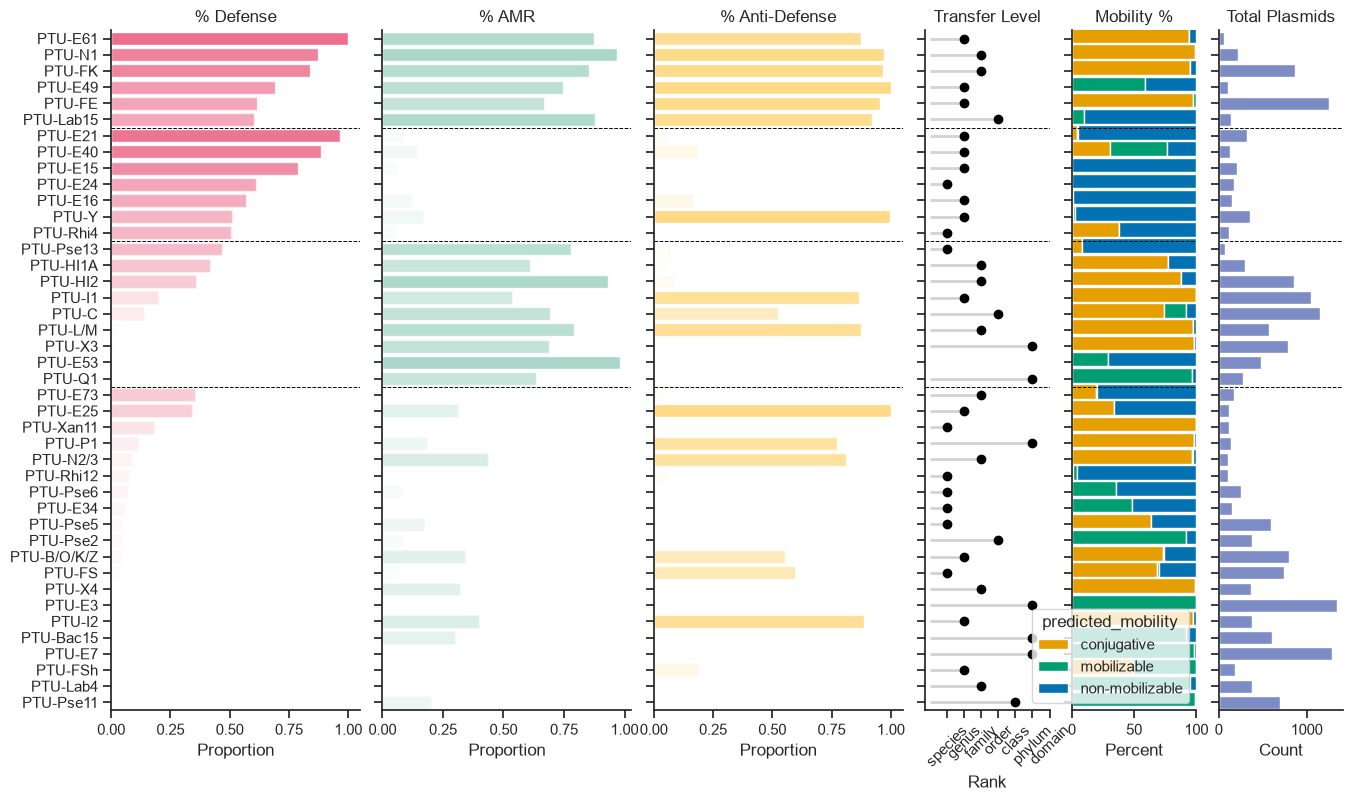

In [9]:
group_order = ['High Def + High AMR', 'High Def + Low AMR', 'Low Def + High AMR', 'Low Def + Low AMR']
grouped['group'] = pd.Categorical(grouped['group'], categories=group_order, ordered=True)
grouped = grouped.sort_values(['group', 'num_def_sys_ge1'], ascending=[True, False])
order = grouped['new_PTU'][::-1]

group_boundaries = []
cum_count = 0
for g in group_order[::-1]:
    count = grouped[grouped['group'] == g].shape[0]
    cum_count += count
    group_boundaries.append(cum_count)
group_boundaries = group_boundaries[:-1]

mobility_counts = extracted_data_filt.groupby(['new_PTU', 'predicted_mobility']).size().unstack(fill_value=0)
mobility_perc = mobility_counts.div(mobility_counts.sum(axis=1), axis=0) * 100
mobility_perc = mobility_perc.loc[order]

ptu_total_counts = (
    extracted_data_filt[extracted_data_filt['new_PTU'] != '']
    .groupby('new_PTU')
    .size()
    .reindex(order)
    .fillna(0)
)

mobility_colors = {
    'conjugative': '#E69F00',
    'non-mobilizable': '#0372B2',
    'mobilizable': '#009E73'
}

for col in mobility_perc.columns:
    if col not in mobility_colors:
        mobility_colors[col] = (0, 0, 0, 0)

taxonomic_ranks = ['species', 'genus', 'family', 'order', 'class', 'phylum', 'domain']
def compute_transfer_level(df):
    for i, level in enumerate(taxonomic_ranks, start=1):
        values = df[level][df[level] != '']
        if values.empty: continue
        if values.nunique() == 1:
            return i - 1 if i > 1 else 1
    return np.nan

transfer_level = extracted_data_filt[extracted_data_filt['new_PTU'] != ''].groupby('new_PTU').apply(compute_transfer_level)
transfer_level = transfer_level.reindex(order)

fig, axes = plt.subplots(
    1,
    6,
    figsize=(16, 8),
    sharey=True,
    gridspec_kw={'width_ratios': [1, 1, 1, 0.5, 0.5, 0.5]}
)

def annotate_group_boundaries(ax):
    for y in group_boundaries:
        ax.axhline(y=y - 0.5, color='black', linestyle='--', linewidth=0.7)

def bar_with_alpha(ax, values, color):
    for y, val in enumerate(values):
        alpha = max(min(val / 1.0, 1), 0)
        ax.barh(y, width=val, color=color, alpha=alpha, height=0.8)

grouped_sorted = grouped.set_index("new_PTU").loc[order].reset_index().rename(columns={'index': 'new_PTU'})

ax = axes[0]
bar_with_alpha(ax, grouped_sorted['num_def_sys_ge1'], color="#ed6f8e")
annotate_group_boundaries(ax)
ax.set_title('% Defense')
ax.set_xlabel('Proportion')
ax.set_ylabel('')
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)

ax = axes[1]
bar_with_alpha(ax, grouped_sorted['num_amr_ge1'], color="#a7d6c7")
annotate_group_boundaries(ax)
ax.set_title('% AMR')
ax.set_xlabel('Proportion')

ax = axes[2]
bar_with_alpha(ax, grouped_sorted['num_antidefense_ge1'], color="#feda86")
annotate_group_boundaries(ax)
ax.set_title('% Anti-Defense')
ax.set_xlabel('Proportion')

ax = axes[3]
for y, ptu in enumerate(order):
    lvl = transfer_level[ptu]
    if pd.notna(lvl):
        ax.hlines(y=y, xmin=0, xmax=lvl, color='lightgray', linewidth=2, alpha=1.0)
        ax.plot(lvl, y, 'o', color='black', alpha=1.0)
annotate_group_boundaries(ax)
ax.set_xticks(range(1, len(taxonomic_ranks) + 1))
ax.set_xticklabels(taxonomic_ranks, rotation=45)
ax.set_title('Transfer Level')
ax.set_xlabel('Rank')

ax = axes[4]
mobility_perc.plot.barh(
    stacked=True,
    ax=ax,
    color=[mobility_colors.get(c, (0, 0, 0, 0)) for c in mobility_perc.columns],
    edgecolor=None
)
for bar in ax.patches:
    bar.set_height(0.9)
annotate_group_boundaries(ax)
ax.set_title('Mobility %')
ax.set_xlabel('Percent')
ax.set_ylabel('')

ax = axes[5]
ax.barh(range(len(order)), ptu_total_counts.values, color="#7d8cc4", height=0.8)
annotate_group_boundaries(ax)
ax.set_title('Total Plasmids')
ax.set_xlabel('Count')
ax.set_ylabel('')

fig.subplots_adjust(left=0.22, right=0.99, bottom=0.10, top=0.95, wspace=0.12)
plt.savefig("plots/fig05_C.pdf")
plt.show()

In [10]:
from collections import Counter
import re
from scipy.stats import fisher_exact

ptu_major_mobility = mobility_counts.idxmax(axis=1)
focal_ptus = set(
    grouped.loc[grouped['group'] == 'High Def + Low AMR', 'new_PTU']
    .astype(str)
    .tolist()
)
focal_ptus = {ptu for ptu in focal_ptus if ptu_major_mobility.get(ptu, None) == 'non-mobilizable'}

all_ptus = set(grouped['new_PTU'].astype(str).tolist())
other_ptus = all_ptus - focal_ptus

print(f"Focal pTUs: {len(focal_ptus)}")
print(f"Other pTUs: {len(other_ptus)}")

def parse_subtypes(cell):
    if pd.isna(cell):
        return []
    items = [x.strip() for x in re.split(r'[,;]', str(cell))]
    return [x for x in items if x and x != '-' and x.lower() != 'unknown']

subtype_to_ptus = {}
for ptu, sub in extracted_data_filt[['new_PTU', 'Unified_subtype_name']].dropna().itertuples(index=False):
    ptu = str(ptu).strip()
    if not ptu or ptu not in all_ptus:
        continue
    for s in parse_subtypes(sub):
        subtype_to_ptus.setdefault(s, set()).add(ptu)

rows = []
for subtype, ptu_set in subtype_to_ptus.items():
    a = len(ptu_set & focal_ptus)
    b = len(focal_ptus) - a
    c = len(ptu_set & other_ptus)
    d = len(other_ptus) - c

    if (a + c) < 3:
        continue

    if min(a, b, c, d) < 0:
        continue

    odds_ratio, pval = fisher_exact([[a, b], [c, d]], alternative='two-sided')
    prev_focal = a / len(focal_ptus) if len(focal_ptus) else np.nan
    prev_other = c / len(other_ptus) if len(other_ptus) else np.nan

    rows.append({
        'subtype': subtype,
        'focal_present': a,
        'focal_absent': b,
        'other_present': c,
        'other_absent': d,
        'prevalence_focal': prev_focal,
        'prevalence_other': prev_other,
        'odds_ratio': odds_ratio,
        'p_value': pval
    })

enrich_df = pd.DataFrame(rows)
if enrich_df.empty:
    print('No subtypes passed the minimum prevalence filter.')
else:
    m = len(enrich_df)
    order_idx = np.argsort(enrich_df['p_value'].values)
    ranked_p = enrich_df['p_value'].values[order_idx]
    q = ranked_p * m / (np.arange(1, m + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)

    enrich_df = enrich_df.iloc[order_idx].copy()
    enrich_df['q_value'] = q
    enrich_df['direction'] = np.where(
        enrich_df['prevalence_focal'] > enrich_df['prevalence_other'],
        'Enriched in focal',
        'Depleted in focal'
    )

    display_cols = [
        'subtype', 'focal_present', 'other_present',
        'prevalence_focal', 'prevalence_other',
        'odds_ratio', 'p_value', 'q_value', 'direction'
    ]
    display(enrich_df[display_cols].head(25))

    hits = enrich_df[(enrich_df['q_value'] < 0.1) & (enrich_df['prevalence_focal'] > enrich_df['prevalence_other'])]
    print(f"Significant enriched subtypes at FDR < 0.1: {len(hits)}")
    if len(hits) > 0:
        display(hits[display_cols].head(20))

Focal pTUs: 6
Other pTUs: 36


,subtype,focal_present,other_present,prevalence_focal,prevalence_other,odds_ratio,p_value,q_value,direction
34,PD-T7-5,2,1,0.333333,0.027778,17.500000,0.048780,0.709756,Enriched in focal
9,RM type I,5,15,0.833333,0.416667,7.000000,0.086634,0.709756,Enriched in focal
38,PD-Lambda-1,2,2,0.333333,0.055556,8.500000,0.090994,0.709756,Enriched in focal
24,PrrC,2,2,0.333333,0.055556,8.500000,0.090994,0.709756,Enriched in focal
5,Uzume,2,2,0.333333,0.055556,8.500000,0.090994,0.709756,Enriched in focal
22,Hachiman,2,4,0.333333,0.111111,4.000000,0.197500,0.962812,Enriched in focal
37,HEC-05,2,4,0.333333,0.111111,4.000000,0.197500,0.962812,Enriched in focal
28,AbiH,2,4,0.333333,0.111111,4.000000,0.197500,0.962812,Enriched in focal
29,SoFic,2,5,0.333333,0.138889,3.100000,0.257388,1.000000,Enriched in focal
14,RloC,0,9,0.000000,0.250000,0.000000,0.311992,1.000000,Depleted in focal


Significant enriched subtypes at FDR < 0.1: 0
